## Dataset helpers testing script

In [1]:
from pathlib import Path

import copy
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

from model.data_utils import (
    ZINBDataset,
    get_X_features,
    get_reference_features,
    load_expression_dataset,
)
from model.model_utils import (
    OrionLoss,
    OrionVAE,
    evaluate_test_set,
    plot_training_results,
    run_dataset_inference,
    train_orion,
)

TRAIN_DATASET = "tissue"  # "tissue" or "circulating"
N_SIGNAL_FEATURES = 32
N_REFERENCE_FEATURES = 64
FEATURE_METHOD = "mannwhitneyu"  # "pydeseq2" or "ttest" or "mannwhitneyu"
BATCH_SIZE = 4
RANDOM_STATE = 42
SEEDS = [7, 11, 19, 29, 37, 55, 79, 97, 123, 151, 333, 555, 777, 999, 2026]
# SEEDS = [7, 11, 19, 29, 37, 55]
EPOCHS = 75
LEARNING_RATE = 1e-3
USE_FEATURE_LEAKAGE = False
MODEL_PATH = Path("model/orion_breast_cancer_model.pth")

counts_matrix, labels = load_expression_dataset(TRAIN_DATASET, data_mode="count")
print(f"Loaded {TRAIN_DATASET} dataset with shape {counts_matrix.shape}")
print(f"Class counts: cancer={int(labels.sum())}, healthy={int((labels == 0).sum())}")


def run_multisplit_experiment(
    counts_df,
    labels_array,
    dataset_tag,
    seeds,
    epochs,
    lr,
    device,
    n_signal_features,
    n_reference_features,
    feature_method,
    batch_size,
    use_feature_leakage=True,
):
    split_rows = []
    best_artifact = None
    best_auc = -1.0

    for split_seed in seeds:
        print("\n" + "=" * 60)
        print(f"{dataset_tag.upper()} | split seed={split_seed}")
        print("=" * 60)

        indices = np.arange(len(labels_array))
        train_val_idx, test_idx = train_test_split(
            indices,
            test_size=0.15,
            stratify=labels_array,
            random_state=split_seed,
        )
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=0.176,
            stratify=labels_array[train_val_idx],
            random_state=split_seed,
        )

        if use_feature_leakage:
            select_counts = counts_df
            select_labels = labels_array
        else:
            select_counts = counts_df.iloc[train_idx]
            select_labels = labels_array[train_idx]

        signal_cols_local = get_X_features(
            select_counts,
            select_labels,
            method=feature_method,
            n_features=n_signal_features,
        )
        ref_cols_local = get_reference_features(
            select_counts,
            n_features=n_reference_features,
        )

        full_dataset_local = ZINBDataset(counts_df, labels_array, signal_cols_local, ref_cols_local)
        train_loader_local = DataLoader(Subset(full_dataset_local, train_idx), batch_size=batch_size, shuffle=True)
        val_loader_local = DataLoader(Subset(full_dataset_local, val_idx), batch_size=batch_size, shuffle=False)
        test_loader_local = DataLoader(Subset(full_dataset_local, test_idx), batch_size=batch_size, shuffle=False)

        model_local = OrionVAE(
            x_dim=len(signal_cols_local),
            r_dim=len(ref_cols_local),
            z_dim=32,
        )
        initial_state_local = copy.deepcopy(model_local.state_dict())

        history_local = train_orion(
            model=model_local,
            train_loader=train_loader_local,
            val_loader=val_loader_local,
            epochs=epochs,
            lr=lr,
            device=device,
            recon_mode="zinb",
        )

        loss_fn_local = OrionLoss(beta=0.01, gamma=10.0, recon_mode="zinb").to(device)
        test_probs_local, test_targets_local = evaluate_test_set(
            model_local,
            test_loader_local,
            loss_fn_local,
            device,
        )

        split_auc = roc_auc_score(test_targets_local, test_probs_local)
        split_acc = accuracy_score(test_targets_local, (test_probs_local > 0.5).astype(int))

        split_rows.append(
            {
                "seed": split_seed,
                "test_auc": split_auc,
                "test_acc": split_acc,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
            }
        )

        if split_auc > best_auc:
            best_auc = split_auc
            best_artifact = {
                "seed": split_seed,
                "model": model_local,
                "history": history_local,
                "signal_cols": signal_cols_local,
                "ref_cols": ref_cols_local,
                "train_idx": train_idx.copy(),
                "val_idx": val_idx.copy(),
                "test_idx": test_idx.copy(),
                "test_loader": test_loader_local,
                "test_probs": test_probs_local,
                "test_targets": test_targets_local,
                "initial_state_dict": copy.deepcopy(initial_state_local),
            }

    summary_df = pd.DataFrame(split_rows)
    print("\n--- Multi-split Summary ---")
    print(summary_df)
    print(
        f"AUC mean={summary_df['test_auc'].mean():.4f} std={summary_df['test_auc'].std(ddof=0):.4f} | "
        f"ACC mean={summary_df['test_acc'].mean():.4f} std={summary_df['test_acc'].std(ddof=0):.4f}"
    )
    print(f"Best split seed={best_artifact['seed']} AUC={best_auc:.4f}")

    return summary_df, best_artifact



Loaded tissue dataset with shape (180, 3538)
Class counts: cancer=120, healthy=60


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
if "signal_cols" not in globals() or "ref_cols" not in globals():
    print("Run the split/feature-selection cell first to initialize signal_cols/ref_cols.")
else:
    dataset_preview = ZINBDataset(counts_matrix, labels, signal_cols, ref_cols)
    preview_loader = DataLoader(dataset_preview, batch_size=BATCH_SIZE, shuffle=True)

    x_batch, r_batch, l_batch, y_batch = next(iter(preview_loader))
    print(f"Batch X Shape: {x_batch.shape}")
    print(f"Batch R Shape: {r_batch.shape}")
    print("Data pipeline ready!")


Run the split/feature-selection cell first to initialize signal_cols/ref_cols.


In [4]:
print(
    f"Preparing 5-split experiment for {TRAIN_DATASET} | "
    f"epochs={EPOCHS} | leakage={USE_FEATURE_LEAKAGE}"
)

Preparing 5-split experiment for tissue | epochs=75 | leakage=False


## Running the model
1. Split data into training and validation sets.
2. Initialize the model with the correct dimensions.
3. Execute the training loop using the train_orion function.

In [5]:
# Model is created inside each split in the multi-split runner.

print("\n--- Starting Multi-Split Training ---")
primary_summary_df, primary_best = run_multisplit_experiment(
    counts_df=counts_matrix,
    labels_array=labels,
    dataset_tag=TRAIN_DATASET,
    seeds=SEEDS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model = primary_best["model"]
history = primary_best["history"]
signal_cols = primary_best["signal_cols"]
ref_cols = primary_best["ref_cols"]
primary_train_idx = primary_best["train_idx"]
primary_val_idx = primary_best["val_idx"]
primary_test_idx = primary_best["test_idx"]
test_loader = primary_best["test_loader"]
test_probs = primary_best["test_probs"]
test_targets = primary_best["test_targets"]

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved best {TRAIN_DATASET} model to '{MODEL_PATH}'")



--- Starting Multi-Split Training ---

TISSUE | split seed=7
Selecting top 32 signal features...
Starting training on cuda for 75 epochs (recon_mode=zinb)...
Epoch 005 | Loss: 749.5357 | Val AUC: 1.0000 | Val Acc: 0.6667
Epoch 010 | Loss: 524.0523 | Val AUC: 1.0000 | Val Acc: 1.0000
Epoch 015 | Loss: 501.7175 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 020 | Loss: 494.0899 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 025 | Loss: 484.6979 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 030 | Loss: 481.7360 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 035 | Loss: 471.6944 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 040 | Loss: 469.9164 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 045 | Loss: 462.3578 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 050 | Loss: 458.2016 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 055 | Loss: 460.7095 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 060 | Loss: 446.3045 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 065 | Loss: 445.2865 | Val AUC: 0.9938 | Val Acc: 0.9630
Epoch 070 | Loss: 438.

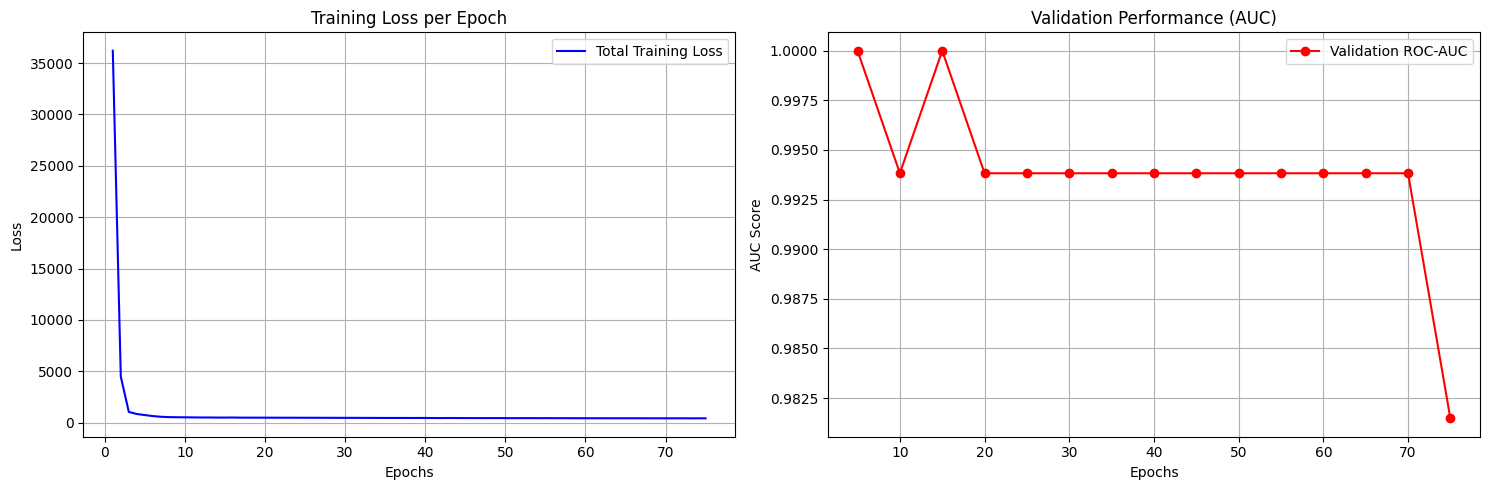

In [6]:
plot_training_results(history)


In [7]:
print("Primary dataset 5-split summary:")
print(primary_summary_df)
print(
    f"AUC mean={primary_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={primary_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {primary_best['seed']}")


Primary dataset 5-split summary:
    seed  test_auc  test_acc  n_train  n_val  n_test
0      7  0.981481  0.888889      126     27      27
1     11  0.981481  0.925926      126     27      27
2     19  1.000000  0.962963      126     27      27
3     29  0.962963  0.925926      126     27      27
4     37  0.938272  0.888889      126     27      27
5     55  0.981481  0.962963      126     27      27
6     79  0.925926  0.851852      126     27      27
7     97  0.987654  0.962963      126     27      27
8    123  0.950617  0.851852      126     27      27
9    151  1.000000  0.962963      126     27      27
10   333  0.969136  0.888889      126     27      27
11   555  1.000000  0.925926      126     27      27
12   777  1.000000  0.925926      126     27      27
13   999  0.993827  0.925926      126     27      27
14  2026  0.944444  0.851852      126     27      27
AUC mean=0.9745 | ACC mean=0.9136
Downstream plots use best-seed model: 19



--- Starting Circulating Multi-Split Training ---

CIRCULATING | split seed=7
Selecting top 32 signal features...
Starting training on cuda for 75 epochs (recon_mode=zinb)...
Epoch 005 | Loss: 471.6714 | Val AUC: 0.9444 | Val Acc: 0.8667
Epoch 010 | Loss: 345.5630 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 015 | Loss: 302.6705 | Val AUC: 0.9630 | Val Acc: 0.8667
Epoch 020 | Loss: 292.9551 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 025 | Loss: 270.5856 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 030 | Loss: 261.7601 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 035 | Loss: 248.6721 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 040 | Loss: 241.8704 | Val AUC: 1.0000 | Val Acc: 1.0000
Epoch 045 | Loss: 237.0642 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 050 | Loss: 227.6289 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch 055 | Loss: 226.9506 | Val AUC: 1.0000 | Val Acc: 1.0000
Epoch 060 | Loss: 230.0486 | Val AUC: 1.0000 | Val Acc: 1.0000
Epoch 065 | Loss: 217.0056 | Val AUC: 1.0000 | Val Acc: 0.9333
Epoch

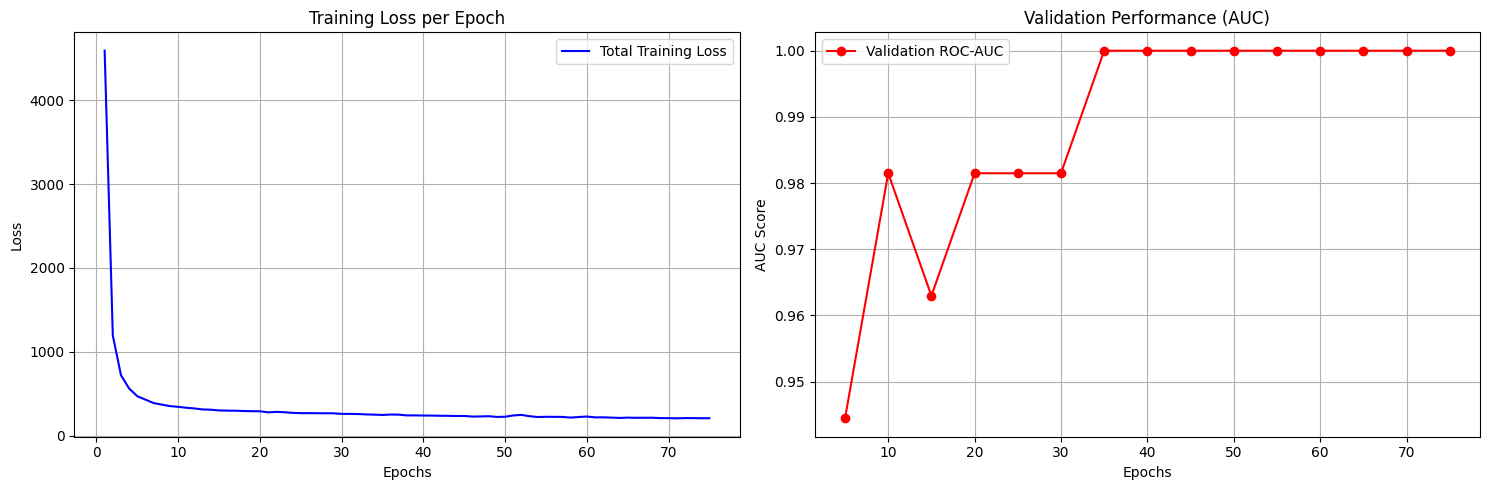

Saved best circulating model to 'model\orion_circulating_model.pth'


In [8]:
# Additional experiment: train and evaluate on circulating RNA (5-split average)
CIRCULATING_EPOCHS = EPOCHS

counts_circ, labels_circ = load_expression_dataset("circulating", data_mode="count")

print("\n--- Starting Circulating Multi-Split Training ---")
circ_summary_df, circ_best = run_multisplit_experiment(
    counts_df=counts_circ,
    labels_array=labels_circ,
    dataset_tag="circulating",
    seeds=SEEDS,
    epochs=CIRCULATING_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model_circ = circ_best["model"]
history_circ = circ_best["history"]
signal_cols_circ = circ_best["signal_cols"]
ref_cols_circ = circ_best["ref_cols"]
circ_train_idx = circ_best["train_idx"]
circ_val_idx = circ_best["val_idx"]
circ_test_idx = circ_best["test_idx"]
test_loader_circ = circ_best["test_loader"]
test_probs_circ = circ_best["test_probs"]
test_targets_circ = circ_best["test_targets"]

plot_training_results(history_circ)

model_circ_path = Path("model/orion_circulating_model.pth")
model_circ_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model_circ.state_dict(), model_circ_path)
print(f"Saved best circulating model to '{model_circ_path}'")


In [9]:
print("Circulating dataset 5-split summary:")
print(circ_summary_df)
print(
    f"AUC mean={circ_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={circ_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {circ_best['seed']}")


Circulating dataset 5-split summary:
    seed  test_auc  test_acc  n_train  n_val  n_test
0      7  1.000000  1.000000       66     15      15
1     11  0.907407  0.866667       66     15      15
2     19  0.888889  0.800000       66     15      15
3     29  1.000000  0.866667       66     15      15
4     37  0.796296  0.600000       66     15      15
5     55  0.981481  0.933333       66     15      15
6     79  0.870370  0.800000       66     15      15
7     97  0.703704  0.600000       66     15      15
8    123  0.814815  0.733333       66     15      15
9    151  0.870370  0.866667       66     15      15
10   333  0.851852  0.866667       66     15      15
11   555  0.944444  0.866667       66     15      15
12   777  0.925926  0.933333       66     15      15
13   999  0.722222  0.800000       66     15      15
14  2026  0.888889  0.866667       66     15      15
AUC mean=0.8778 | ACC mean=0.8267
Downstream plots use best-seed model: 7


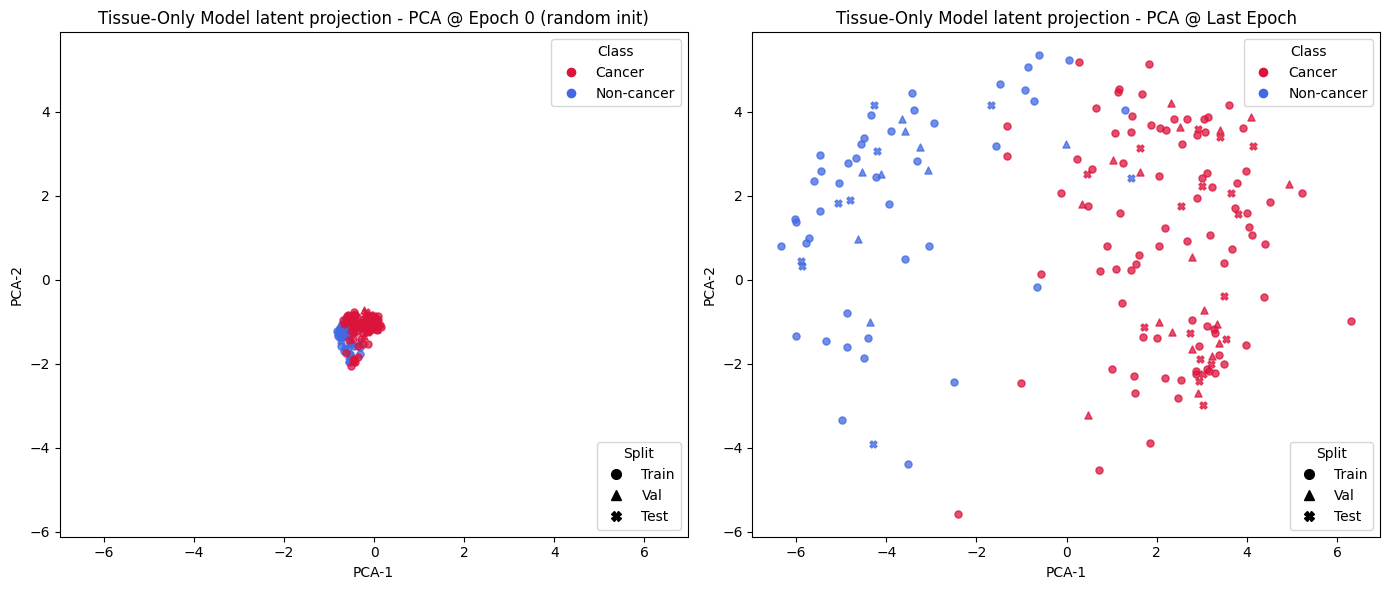

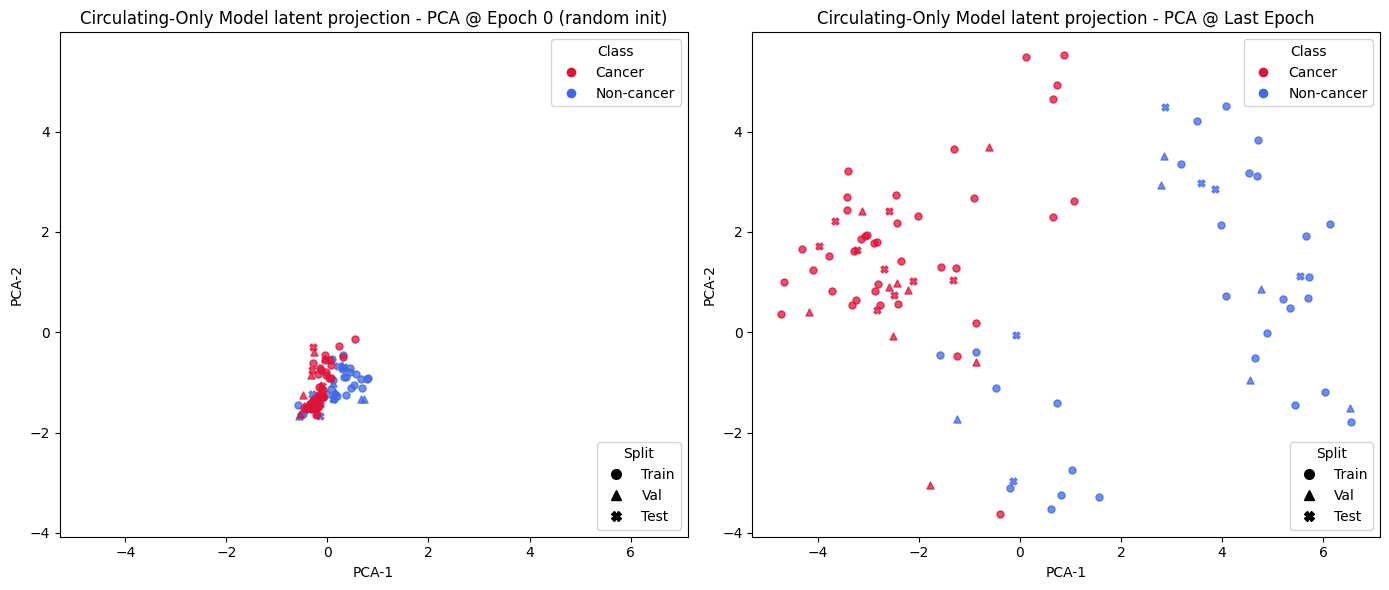

In [10]:
from vis_utils import plot_binary_epoch_pca_comparison

# 1) Tissue model latent projection: epoch 0 vs last epoch (PCA only)
tissue_dataset = ZINBDataset(
    counts_matrix,
    labels,
    signal_cols,
    ref_cols,
    task_type="binary",
)
plot_binary_epoch_pca_comparison(
    model_obj=model,
    initial_state_dict=primary_best["initial_state_dict"],
    dataset_obj=tissue_dataset,
    split_index_map={
        "train": primary_train_idx,
        "val": primary_val_idx,
        "test": primary_test_idx,
    },
    batch_size=BATCH_SIZE,
    device=device,
    title="Tissue-Only Model latent projection",
)

# 2) Circulating model latent projection: epoch 0 vs last epoch (PCA only)
if "model_circ" in globals():
    circulating_dataset = ZINBDataset(
        counts_circ,
        labels_circ,
        signal_cols_circ,
        ref_cols_circ,
        task_type="binary",
    )
    plot_binary_epoch_pca_comparison(
        model_obj=model_circ,
        initial_state_dict=circ_best["initial_state_dict"],
        dataset_obj=circulating_dataset,
        split_index_map={
            "train": circ_train_idx,
            "val": circ_val_idx,
            "test": circ_test_idx,
        },
        batch_size=BATCH_SIZE,
        device=device,
        title="Circulating-Only Model latent projection",
    )
else:
    print("Run the circulating multi-split cell first to view circulating diagnostics.")


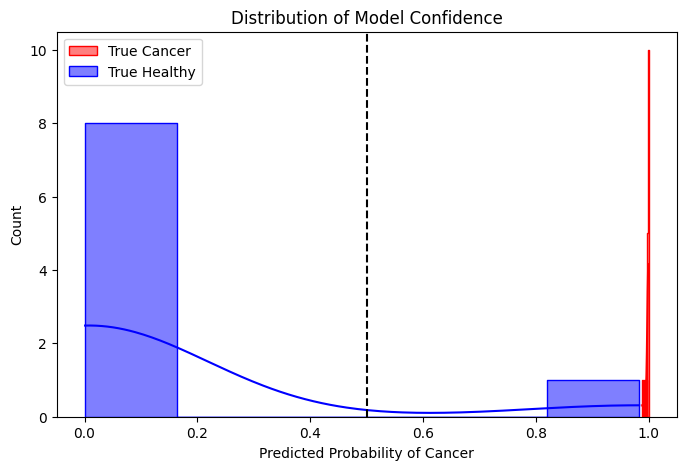

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(test_probs[test_targets == 1], color="red", label="True Cancer", kde=True, element="step")
sns.histplot(test_probs[test_targets == 0], color="blue", label="True Healthy", kde=True, element="step")
plt.axvline(0.5, color="black", linestyle="--")
plt.title("Distribution of Model Confidence")
plt.xlabel("Predicted Probability of Cancer")
plt.legend()
plt.show()


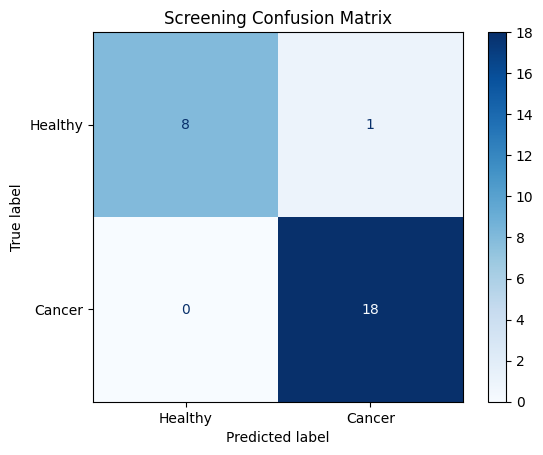

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

preds_binary = (test_probs > 0.5).astype(int)
cm = confusion_matrix(test_targets, preds_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Cancer"])
disp.plot(cmap="Blues")
plt.title("Screening Confusion Matrix")
plt.show()


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score

INFERENCE_DATASET = "circulating" if TRAIN_DATASET == "tissue" else "tissue"
inference_counts, inference_labels = load_expression_dataset(INFERENCE_DATASET, data_mode="count")

signal_overlap = len(set(signal_cols).intersection(inference_counts.columns))
ref_overlap = len(set(ref_cols).intersection(inference_counts.columns))
print(
    f"Feature overlap with {INFERENCE_DATASET}: signal {signal_overlap}/{len(signal_cols)}, "
    f"reference {ref_overlap}/{len(ref_cols)}"
)

inference_probs, inference_targets = run_dataset_inference(
    model=model,
    counts_df=inference_counts,
    signal_features=signal_cols,
    ref_features=ref_cols,
    labels=inference_labels,
    batch_size=BATCH_SIZE,
    device=device,
)

inference_binary = (inference_probs > 0.5).astype(int)
inference_auc = roc_auc_score(inference_targets, inference_probs)
inference_acc = accuracy_score(inference_targets, inference_binary)

print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference AUC: {inference_auc:.4f}")
print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference ACC: {inference_acc:.4f}")


Feature overlap with circulating: signal 18/32, reference 27/64
tissue -> circulating inference AUC: 0.3799
tissue -> circulating inference ACC: 0.4896


# multiclass dataset - pancancer model

Diagnostic objective:
- Stage 1: cancer vs non-cancer (benign included in non-cancer)
- Stage 2: cancer-type classifier on predicted cancer samples

In [14]:
# Phase 1 diagnostics: serum pancancer matrix + metadata loader
import numpy as np
from model.data_utils import load_serum_pancancer_dataset

panc_counts, panc_meta, panc_maps, panc_info = load_serum_pancancer_dataset(data_mode="normalized", return_info=True)

print("Pancancer expression shape [samples, features]:", panc_counts.shape)
print("Data mode:", panc_info["data_mode"], "| inferred:", panc_info["inferred_data_mode"])
print("Aligned metadata rows:", panc_meta.shape[0])
print("Sample index alignment:", panc_counts.index.equals(panc_meta.index))

print("\nDisease-state counts:")
print(panc_meta["Disease State"].value_counts())

print("\nStage1 group counts:")
print(panc_meta["stage1_group"].value_counts())

print("\nStage1 label distribution (1=cancer, 0=non-cancer):")
print(panc_meta["stage1_label"].value_counts().sort_index())

cancer_only = panc_meta[panc_meta["stage2_label"] >= 0]
print("\nStage2 cancer classes:", cancer_only["stage2_label"].nunique())
print("Stage2 class map (first 10):")
print(list(panc_maps["stage2_class_to_index"].items())[:10])

values = panc_counts.to_numpy(dtype=np.float32, copy=False)
print("\nExpression matrix stats:")
print(f"min={values.min():.4f}, max={values.max():.4f}, mean={values.mean():.4f}, std={values.std():.4f}")
print(f"zero fraction={(values == 0).mean():.6f}")



Pancancer expression shape [samples, features]: (16190, 2565)
Data mode: normalized | inferred: normalized
Aligned metadata rows: 16190
Sample index alignment: True

Disease-state counts:
Disease State
no cancer                                                       5643
lung cancer                                                     1699
colorectal cancer                                               1596
gastric cancer                                                  1418
prostate cancer                                                 1027
pancreatic cancer                                                851
breast cancer                                                    675
esophageal squamous cell cancer                                  566
biliary tract cancer                                             402
ovarian cancer                                                   400
bladder cancer                                                   399
hepatocellular cancer                  

## Phase 3 - Stage 1 + Stage 2 training and latent analysis

This section adds:
- Stage 1 training: cancer vs non-cancer
- Stage 2 training: 13-way cancer type classification (cancer-only samples)
- Per-epoch training loss and validation curves for both stages
- Latent space analysis for stage 1 and stage 2


In [15]:
import copy
import numpy as np
import torch
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Subset

from model.data_utils import (
    ZINBDataset,
    get_X_features,
    get_reference_features,
    load_serum_pancancer_dataset,
)
from model.model_utils import OrionLoss, OrionVAE, evaluate_test_set, train_orion
from vis_utils import (
    _safe_macro_auc,
    build_stage2_per_class_metrics,
    plot_history_with_validation,
    plot_binary_epoch_pca_comparison,
    plot_stage2_diagnostics,
)


def stratified_train_val_test_indices(labels, test_size=0.15, val_size=0.15, random_state=42):
    labels = np.asarray(labels)
    indices = np.arange(len(labels))

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        stratify=labels,
        random_state=random_state,
    )

    val_frac_of_trainval = val_size / (1.0 - test_size)
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_frac_of_trainval,
        stratify=labels[train_val_idx],
        random_state=random_state,
    )

    return train_idx, val_idx, test_idx


def select_multiclass_signal_features_anova(counts_df, labels, n_features=256):
    y = np.asarray(labels).astype(int)
    X = counts_df.to_numpy(dtype=np.float32, copy=False)

    scores, _ = f_classif(X, y)
    scores = np.nan_to_num(scores, nan=-np.inf, posinf=-np.inf, neginf=-np.inf)

    top_idx = np.argsort(scores)[::-1][:n_features]
    return counts_df.columns[top_idx].tolist()


def compute_multiclass_class_weights(train_labels, n_classes, device):
    y = np.asarray(train_labels).astype(int)
    all_classes = np.arange(n_classes, dtype=int)
    present_classes = np.unique(y)

    present_weights = compute_class_weight(
        class_weight="balanced",
        classes=present_classes,
        y=y,
    )
    weight_map = {int(cls): float(w) for cls, w in zip(present_classes, present_weights)}
    weights_np = np.array([weight_map.get(int(cls), 1.0) for cls in all_classes], dtype=np.float32)
    weights_t = torch.tensor(weights_np, dtype=torch.float32, device=device)
    return weights_t, weights_np



Selecting top 32 signal features...
Starting training on cuda for 40 epochs (recon_mode=mse)...
Epoch 005 | Loss: 4331.8255 | Val AUC: 0.9384 | Val Acc: 0.8991
Epoch 010 | Loss: 3976.2207 | Val AUC: 0.9501 | Val Acc: 0.9098
Epoch 015 | Loss: 3891.7655 | Val AUC: 0.9529 | Val Acc: 0.9140
Epoch 020 | Loss: 3756.8006 | Val AUC: 0.9570 | Val Acc: 0.9193
Epoch 025 | Loss: 3703.9447 | Val AUC: 0.9582 | Val Acc: 0.9193
Epoch 030 | Loss: 3687.2412 | Val AUC: 0.9559 | Val Acc: 0.9177
Epoch 035 | Loss: 3678.4811 | Val AUC: 0.9590 | Val Acc: 0.9259
Epoch 040 | Loss: 3662.5716 | Val AUC: 0.9595 | Val Acc: 0.9275


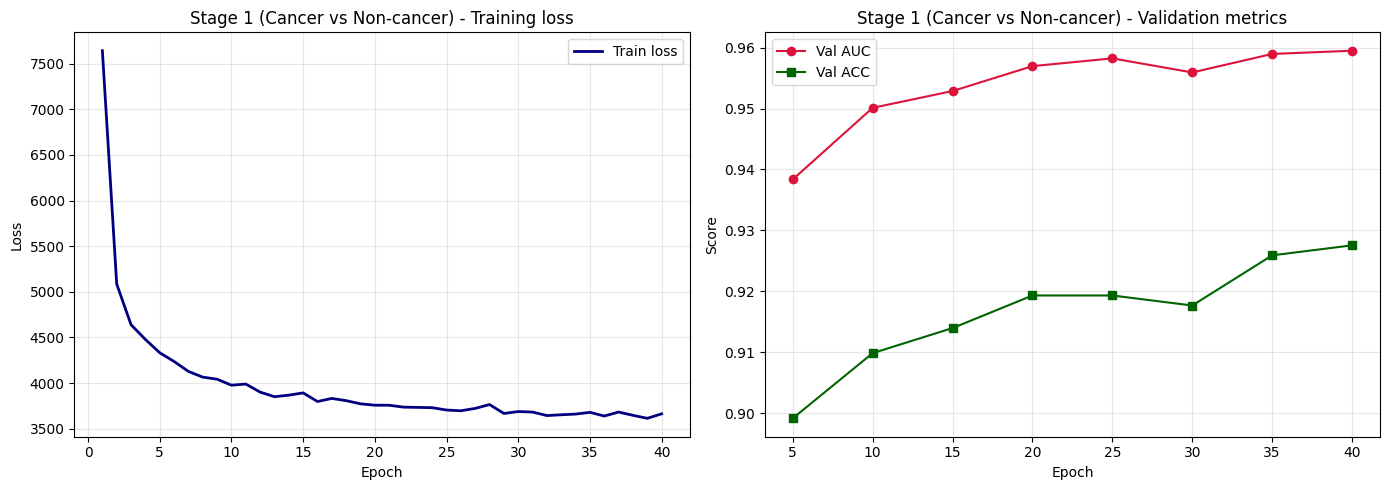

------------------------------
FINAL TEST RESULTS (N=2429)
------------------------------
Test Loss:  3638.5025
ROC-AUC:    0.9567
Accuracy:   0.9259
Precision:  0.9118 (Positive Predictive Value)
Recall:     0.9731 (Sensitivity)
F1-Score:   0.9415
------------------------------
Stage 1 test AUC: 0.9567 | ACC: 0.9259


In [16]:
# Stage 1: cancer vs non-cancer
if "panc_counts" not in globals() or "panc_meta" not in globals() or "panc_maps" not in globals():
    panc_counts, panc_meta, panc_maps, panc_info = load_serum_pancancer_dataset(data_mode="normalized", return_info=True)

PANC_SIGNAL_STAGE1 = 32
PANC_REF_STAGE1 = 64
PANC_STAGE1_EPOCHS = 40
PANC_BATCH_SIZE = 32
PANC_FEATURE_METHOD_STAGE1 = "mannwhitneyu"
PANC_STAGE1_SEED = 42

labels_stage1 = panc_meta["stage1_label"].values.astype(np.float32)

train_idx_s1, val_idx_s1, test_idx_s1 = stratified_train_val_test_indices(
    labels_stage1,
    test_size=0.15,
    val_size=0.15,
    random_state=PANC_STAGE1_SEED,
)

train_counts_s1 = panc_counts.iloc[train_idx_s1]
train_labels_s1 = labels_stage1[train_idx_s1]

signal_cols_stage1 = get_X_features(
    train_counts_s1,
    train_labels_s1,
    method=PANC_FEATURE_METHOD_STAGE1,
    n_features=PANC_SIGNAL_STAGE1,
)
ref_cols_stage1 = get_reference_features(train_counts_s1, n_features=PANC_REF_STAGE1)

stage1_dataset = ZINBDataset(
    panc_counts,
    labels_stage1,
    signal_cols_stage1,
    ref_cols_stage1,
    task_type="binary",
)

stage1_train_loader = DataLoader(Subset(stage1_dataset, train_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=True)
stage1_val_loader = DataLoader(Subset(stage1_dataset, val_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=False)
stage1_test_loader = DataLoader(Subset(stage1_dataset, test_idx_s1), batch_size=PANC_BATCH_SIZE, shuffle=False)

model_stage1 = OrionVAE(
    x_dim=len(signal_cols_stage1),
    r_dim=len(ref_cols_stage1),
    z_dim=32,
    n_classes=1,
    task_type="binary",
)
stage1_initial_state_dict = copy.deepcopy(model_stage1.state_dict())

history_stage1 = train_orion(
    model=model_stage1,
    train_loader=stage1_train_loader,
    val_loader=stage1_val_loader,
    epochs=PANC_STAGE1_EPOCHS,
    lr=1e-3,
    device=device,
    recon_mode="mse",
)

plot_history_with_validation(history_stage1, title="Stage 1 (Cancer vs Non-cancer)", eval_every=5)

loss_stage1 = OrionLoss(beta=0.01, gamma=10.0, n_classes=1, task_type="binary", recon_mode="mse").to(device)
stage1_test_probs, stage1_test_targets = evaluate_test_set(
    model_stage1,
    stage1_test_loader,
    loss_stage1,
    device,
)

stage1_test_auc = roc_auc_score(stage1_test_targets, stage1_test_probs)
stage1_test_acc = accuracy_score(stage1_test_targets, (stage1_test_probs > 0.5).astype(int))
print(f"Stage 1 test AUC: {stage1_test_auc:.4f} | ACC: {stage1_test_acc:.4f}")

stage1_artifact = {
    "model": model_stage1,
    "dataset": stage1_dataset,
    "history": history_stage1,
    "signal_cols": signal_cols_stage1,
    "ref_cols": ref_cols_stage1,
    "split_idx": {"train": train_idx_s1, "val": val_idx_s1, "test": test_idx_s1},
    "initial_state_dict": stage1_initial_state_dict,
}


Stage 2 samples: 9921 | classes: 13
disease_state_normalized
lung cancer                        1699
colorectal cancer                  1596
gastric cancer                     1418
prostate cancer                    1027
pancreatic cancer                   851
breast cancer                       675
esophageal squamous cell cancer     566
biliary tract cancer                402
ovarian cancer                      400
bladder cancer                      399
hepatocellular cancer               348
bone and soft tissue sarcomas       299
intraparenchymal brain tumors       241
Name: count, dtype: int64

Stage 2 class weights (train split)
  biliary tract cancer: 1.8942
  bladder cancer: 1.9145
  bone and soft tissue sarcomas: 2.5558
  breast cancer: 1.1293
  colorectal cancer: 0.4782
  esophageal squamous cell cancer: 1.3489
  gastric cancer: 0.5385
  hepatocellular cancer: 2.1892
  intraparenchymal brain tumors: 3.1607
  lung cancer: 0.4492
  ovarian cancer: 1.9077
  pancreatic cancer: 0

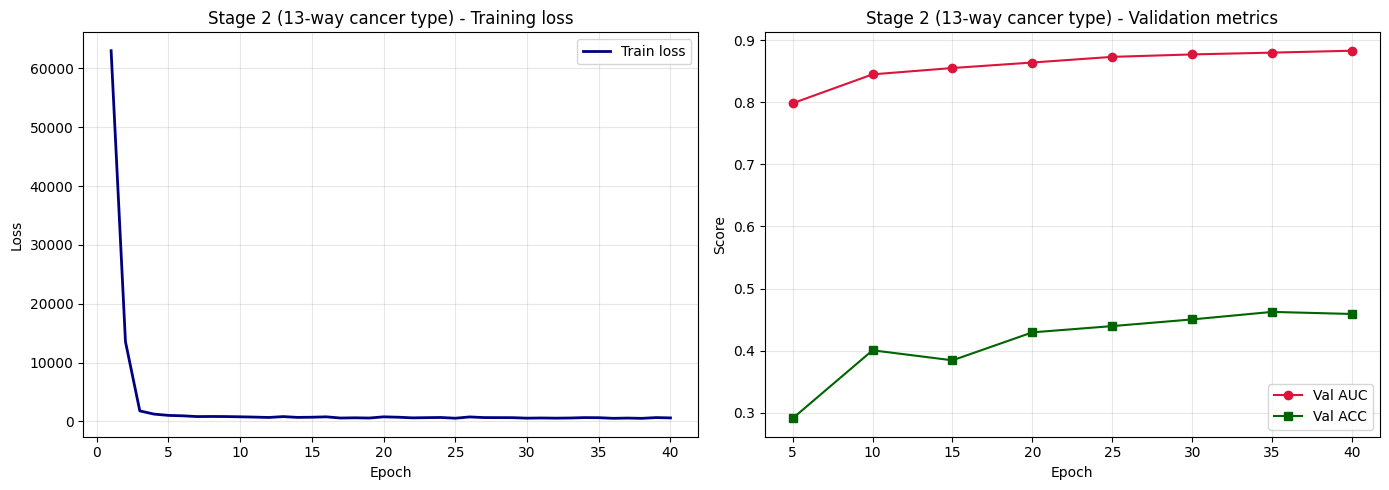

------------------------------
FINAL TEST RESULTS (N=1489)
------------------------------
Test Loss:        454.5045
ROC-AUC (macro):  0.8833
Accuracy:         0.4493
F1 macro:         0.4236
F1 weighted:      0.4087
------------------------------

Stage 2 overall metrics (secondary summary)
AUC (macro OVR): 0.8833 | ACC: 0.4493 | F1-macro: 0.4236

Stage 2 per-class metrics (test split)
 class_idx                      class_name  support  precision  recall     f1  roc_auc_ovr  pr_auc_ovr
         0            biliary tract cancer       60     0.0973  0.1833 0.1272       0.7671      0.0892
         1                  bladder cancer       60     0.4194  0.8667 0.5652       0.9527      0.4425
         2   bone and soft tissue sarcomas       45     0.5918  0.6444 0.6170       0.9269      0.6502
         3                   breast cancer      101     0.6454  0.9010 0.7521       0.9834      0.7323
         4               colorectal cancer      240     0.2759  0.0333 0.0595       0.7274     

In [17]:
# Stage 2: cancer-only, 13-type multiclass classification
cancer_mask = panc_meta["stage2_label"].values >= 0
counts_stage2 = panc_counts.loc[cancer_mask]
meta_stage2 = panc_meta.loc[cancer_mask].copy()
labels_stage2 = meta_stage2["stage2_label"].values.astype(int)

n_classes_stage2 = int(labels_stage2.max()) + 1
print("Stage 2 samples:", len(labels_stage2), "| classes:", n_classes_stage2)
print(meta_stage2["disease_state_normalized"].value_counts())

PANC_SIGNAL_STAGE2 = 32
PANC_REF_STAGE2 = 64
PANC_STAGE2_EPOCHS = 40
PANC_BATCH_SIZE_STAGE2 = 32
PANC_STAGE2_SEED = 42

train_idx_s2, val_idx_s2, test_idx_s2 = stratified_train_val_test_indices(
    labels_stage2,
    test_size=0.15,
    val_size=0.15,
    random_state=PANC_STAGE2_SEED,
)

train_counts_s2 = counts_stage2.iloc[train_idx_s2]
train_labels_s2 = labels_stage2[train_idx_s2]

signal_cols_stage2 = select_multiclass_signal_features_anova(
    train_counts_s2,
    train_labels_s2,
    n_features=PANC_SIGNAL_STAGE2,
)
ref_cols_stage2 = get_reference_features(train_counts_s2, n_features=PANC_REF_STAGE2)

stage2_class_weights_t, stage2_class_weights_np = compute_multiclass_class_weights(
    train_labels=train_labels_s2,
    n_classes=n_classes_stage2,
    device=device,
)

print("\nStage 2 class weights (train split)")
for cls_idx, w in enumerate(stage2_class_weights_np):
    print(f"  {panc_maps['stage2_index_to_class'][cls_idx]}: {w:.4f}")

stage2_dataset = ZINBDataset(
    counts_stage2,
    labels_stage2,
    signal_cols_stage2,
    ref_cols_stage2,
    task_type="multiclass",
)

stage2_train_loader = DataLoader(Subset(stage2_dataset, train_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=True)
stage2_val_loader = DataLoader(Subset(stage2_dataset, val_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=False)
stage2_test_loader = DataLoader(Subset(stage2_dataset, test_idx_s2), batch_size=PANC_BATCH_SIZE_STAGE2, shuffle=False)

model_stage2 = OrionVAE(
    x_dim=len(signal_cols_stage2),
    r_dim=len(ref_cols_stage2),
    z_dim=32,
    n_classes=n_classes_stage2,
    task_type="multiclass",
)

history_stage2 = train_orion(
    model=model_stage2,
    train_loader=stage2_train_loader,
    val_loader=stage2_val_loader,
    epochs=PANC_STAGE2_EPOCHS,
    lr=1e-3,
    device=device,
    recon_mode="mse",
    class_weights=stage2_class_weights_t,
)

plot_history_with_validation(history_stage2, title="Stage 2 (13-way cancer type)", eval_every=5)

loss_stage2 = OrionLoss(
    beta=0.01,
    gamma=10.0,
    n_classes=n_classes_stage2,
    task_type="multiclass",
    recon_mode="mse",
    class_weights=stage2_class_weights_t,
).to(device)
stage2_test_probs, stage2_test_targets = evaluate_test_set(
    model_stage2,
    stage2_test_loader,
    loss_stage2,
    device,
)

stage2_pred = np.argmax(stage2_test_probs, axis=1)
stage2_test_acc = accuracy_score(stage2_test_targets, stage2_pred)
stage2_test_f1_macro = f1_score(stage2_test_targets, stage2_pred, average="macro", zero_division=0)
stage2_test_auc_macro = _safe_macro_auc(stage2_test_targets, stage2_test_probs)

print("\nStage 2 overall metrics (secondary summary)")
print(
    f"AUC (macro OVR): {stage2_test_auc_macro:.4f} | "
    f"ACC: {stage2_test_acc:.4f} | F1-macro: {stage2_test_f1_macro:.4f}"
)

stage2_class_map = panc_maps["stage2_index_to_class"]
stage2_per_class_metrics = build_stage2_per_class_metrics(
    y_true=stage2_test_targets,
    y_pred=stage2_pred,
    y_prob=stage2_test_probs,
    class_index_to_name=stage2_class_map,
)

print("\nStage 2 per-class metrics (test split)")
metrics_display = stage2_per_class_metrics.copy()
for col in ["precision", "recall", "f1", "roc_auc_ovr", "pr_auc_ovr"]:
    metrics_display[col] = metrics_display[col].round(4)
print(metrics_display.to_string(index=False))

stage2_artifact = {
    "model": model_stage2,
    "dataset": stage2_dataset,
    "history": history_stage2,
    "signal_cols": signal_cols_stage2,
    "ref_cols": ref_cols_stage2,
    "split_idx": {"train": train_idx_s2, "val": val_idx_s2, "test": test_idx_s2},
    "class_map": stage2_class_map,
    "class_weights": stage2_class_weights_np,
    "test_probs": stage2_test_probs,
    "test_targets": stage2_test_targets,
    "test_pred": stage2_pred,
    "per_class_metrics": stage2_per_class_metrics,
}



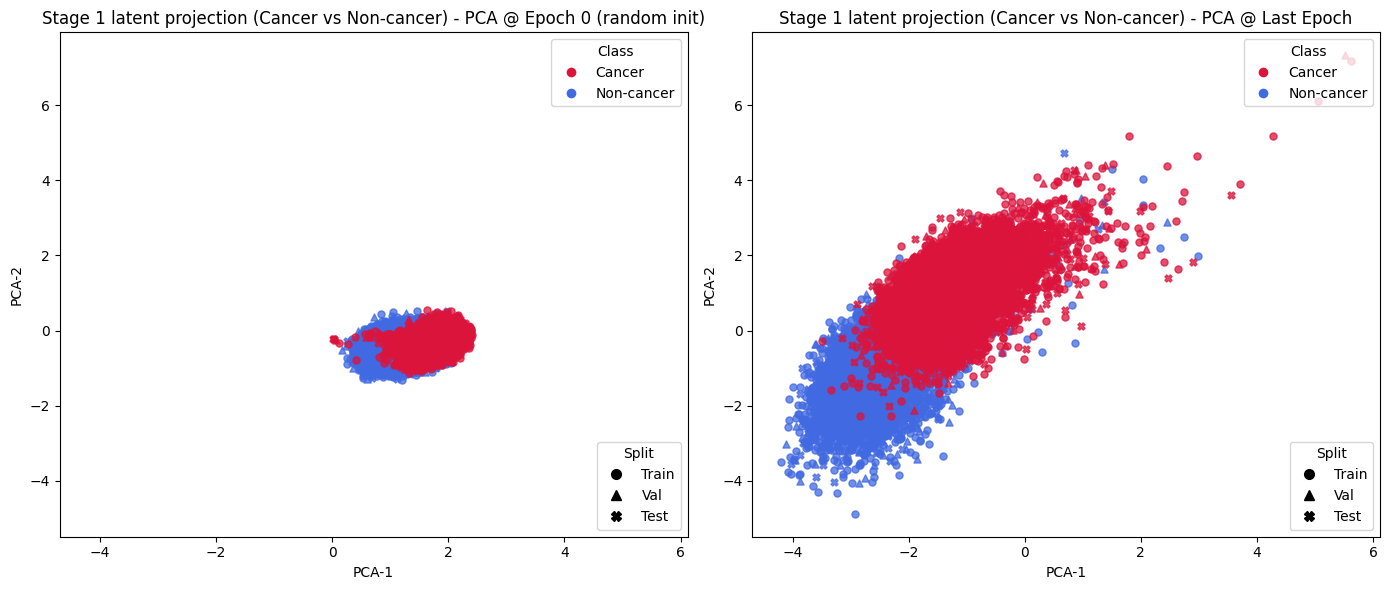


Stage 2 per-class metrics (test split)
------------------------------------------------------------------------------------------
 class_idx                      class_name  support  precision  recall     f1  roc_auc_ovr  pr_auc_ovr
         0            biliary tract cancer       60     0.0973  0.1833 0.1272       0.7671      0.0892
         1                  bladder cancer       60     0.4194  0.8667 0.5652       0.9527      0.4425
         2   bone and soft tissue sarcomas       45     0.5918  0.6444 0.6170       0.9269      0.6502
         3                   breast cancer      101     0.6454  0.9010 0.7521       0.9834      0.7323
         4               colorectal cancer      240     0.2759  0.0333 0.0595       0.7274      0.2847
         5 esophageal squamous cell cancer       85     0.5287  0.5412 0.5349       0.9448      0.5771
         6                  gastric cancer      213     0.4118  0.6901 0.5158       0.8494      0.3495
         7           hepatocellular cancer   

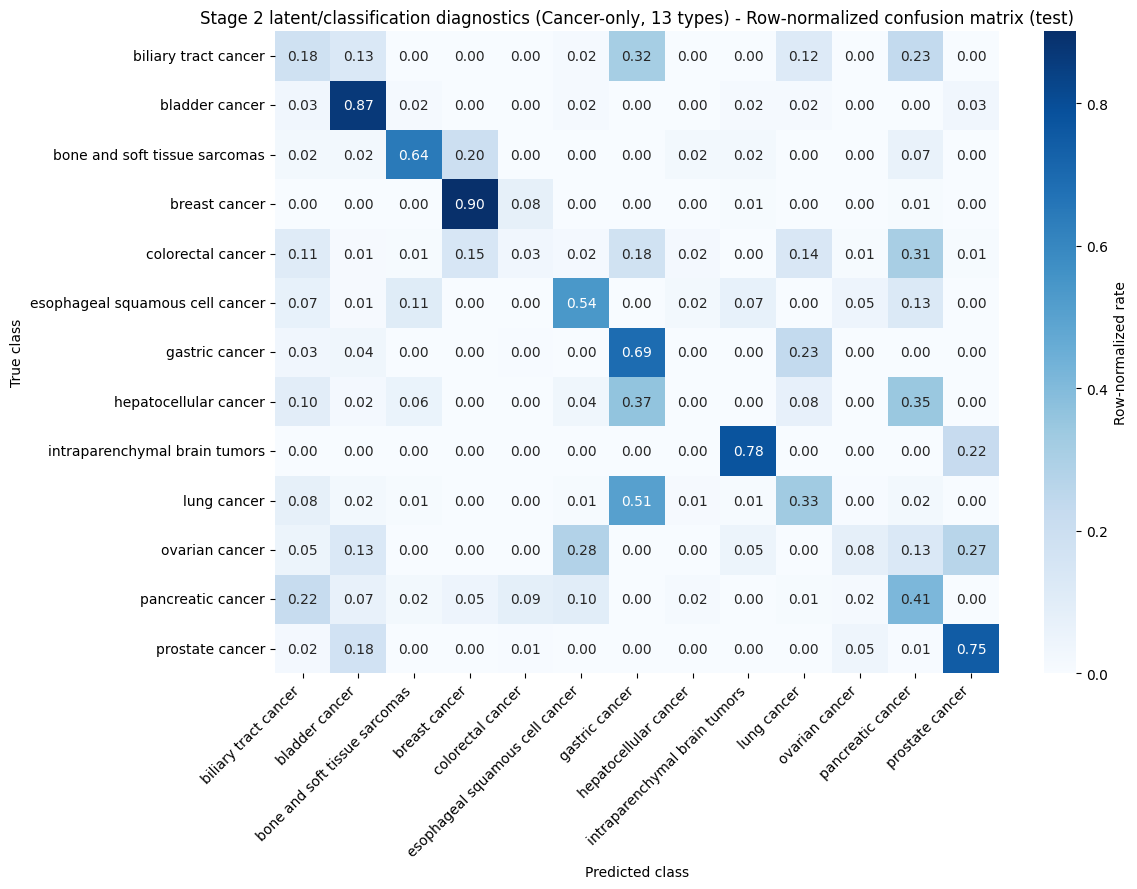

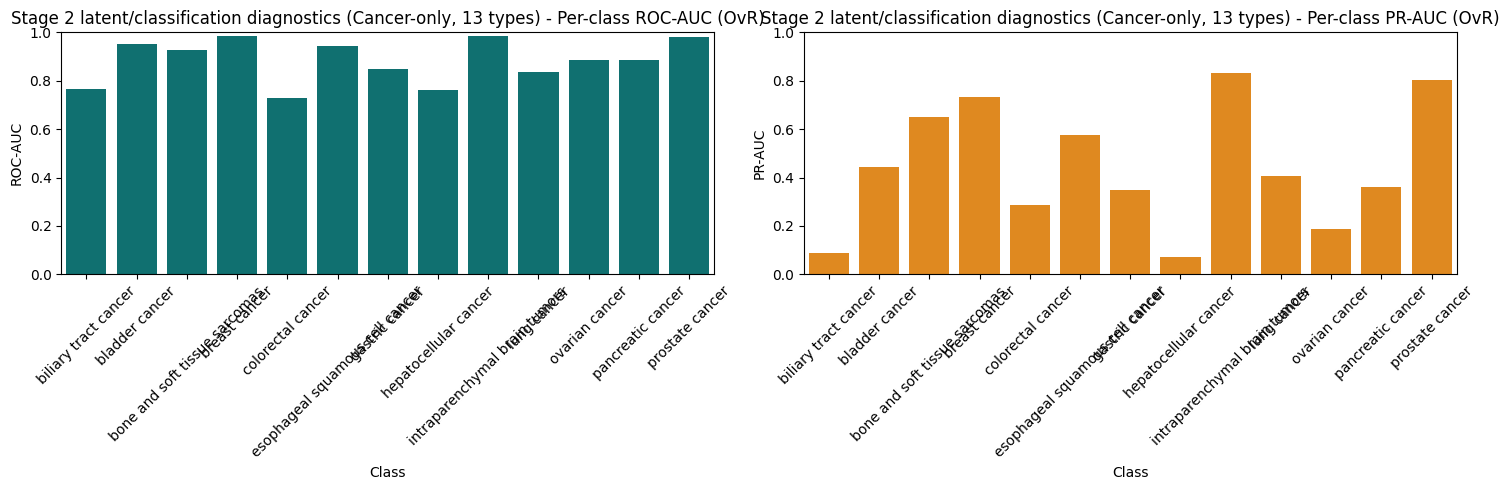

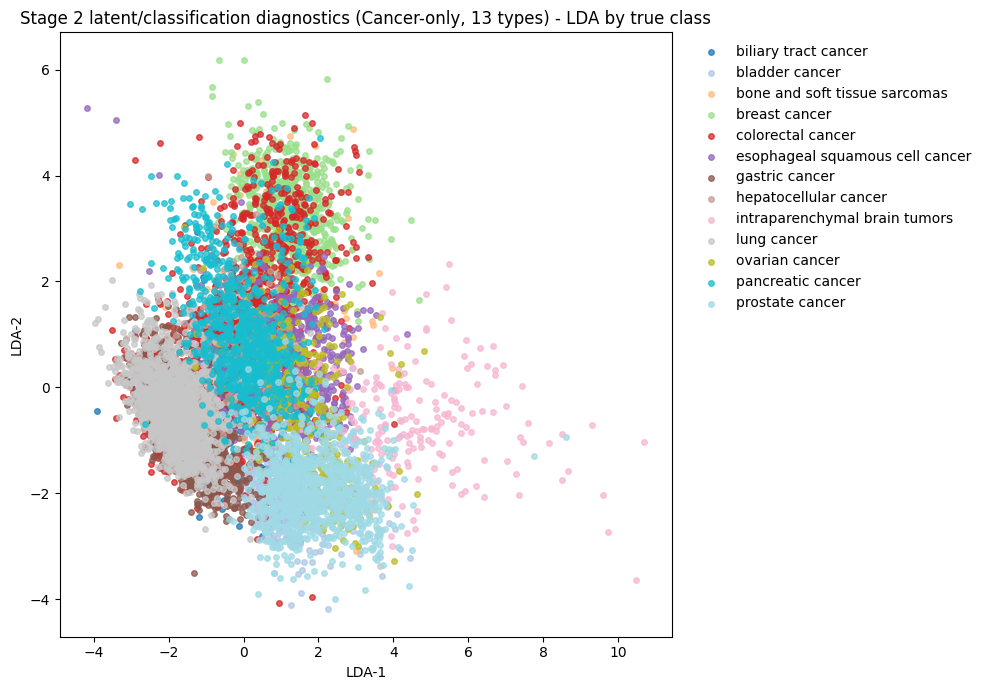

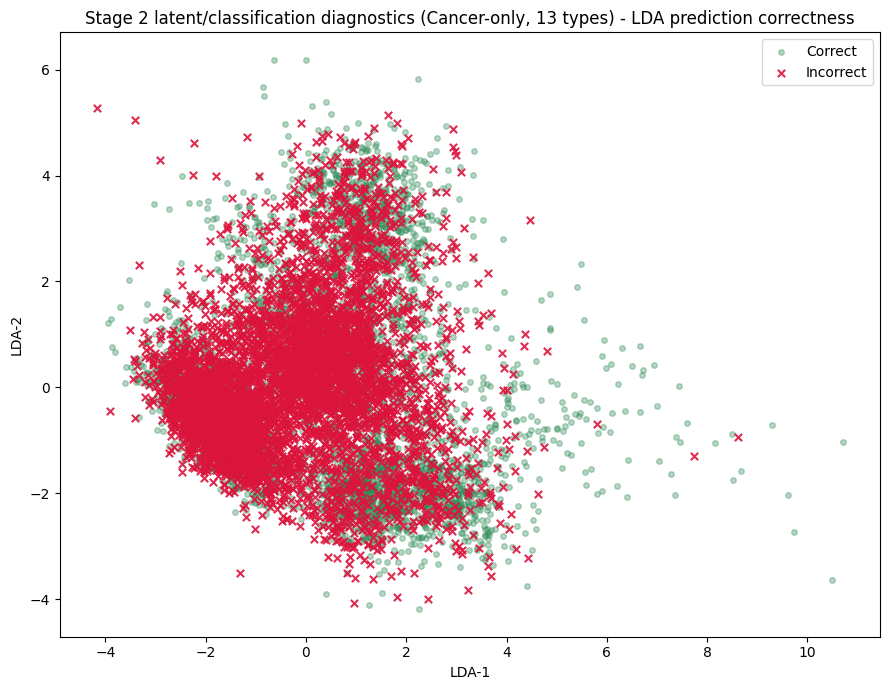

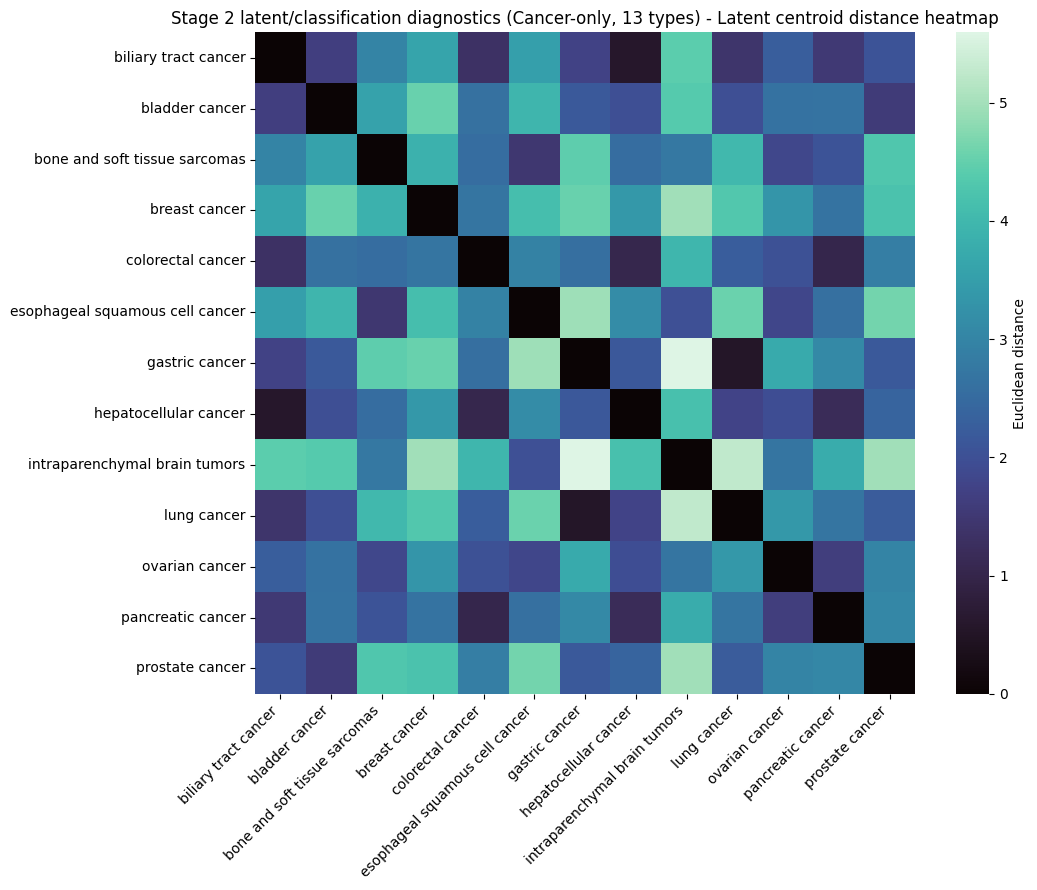

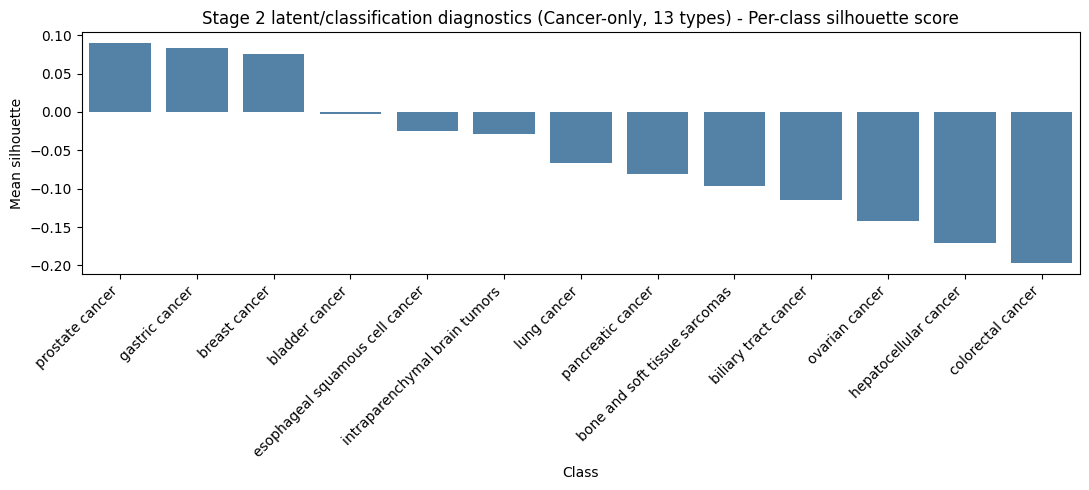

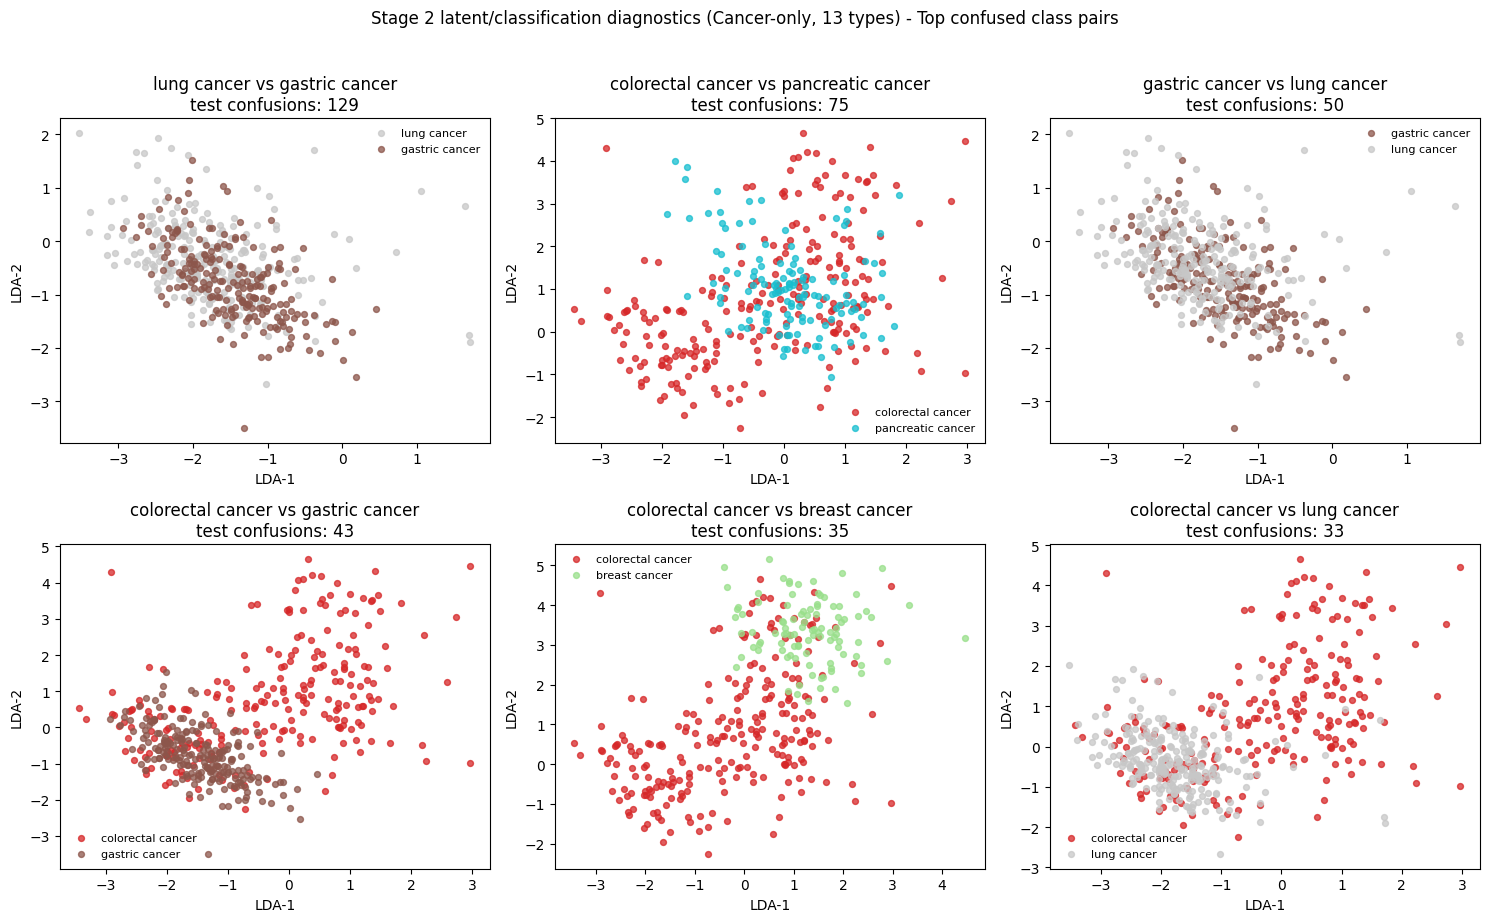

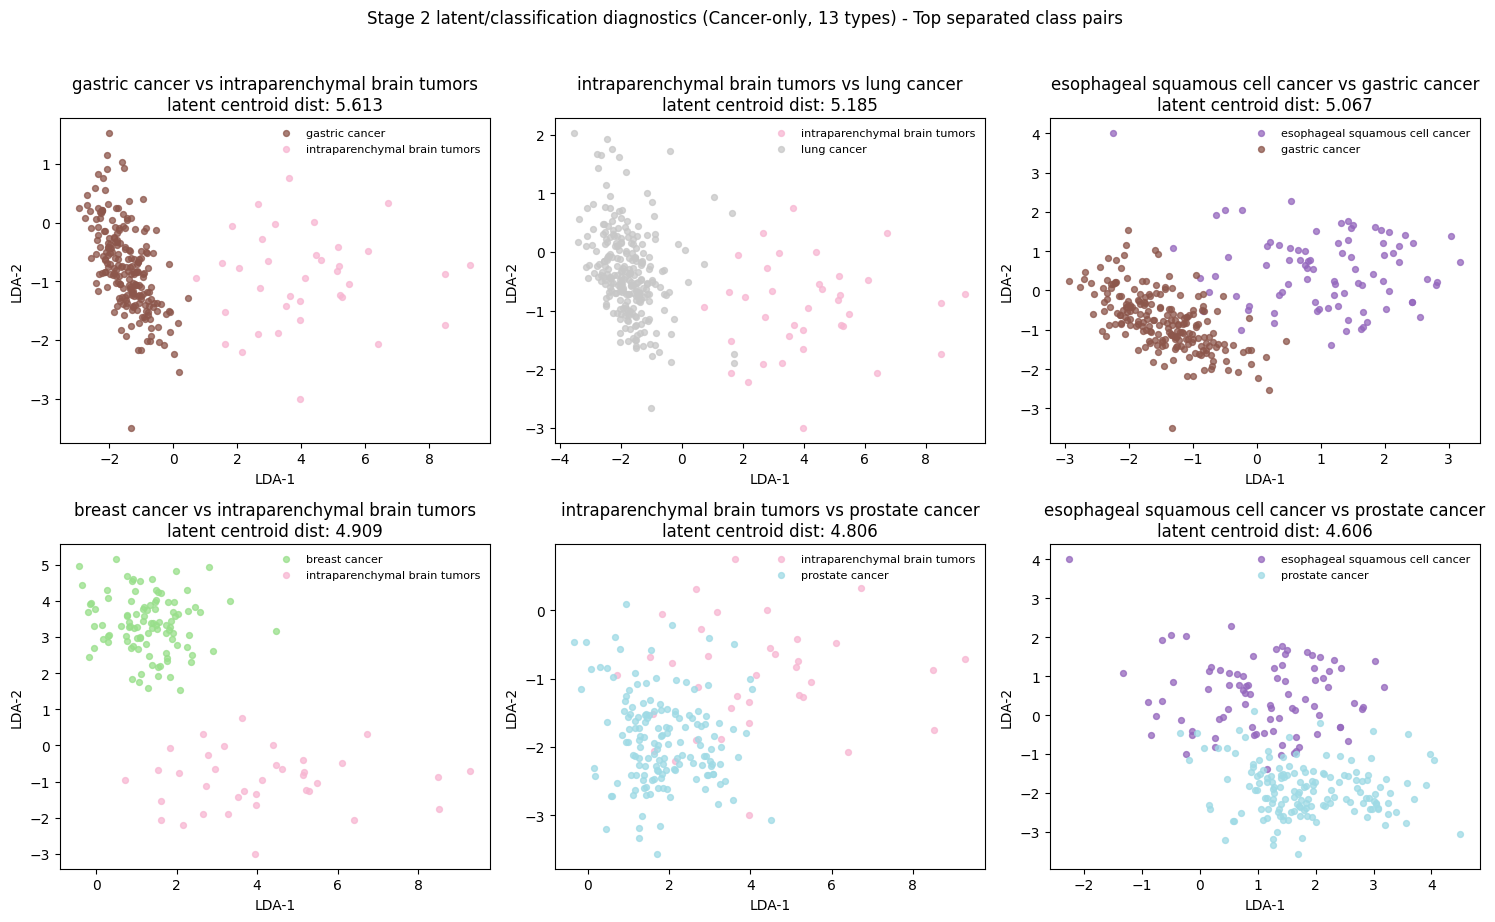

In [18]:
# Latent space analysis
plot_binary_epoch_pca_comparison(
    model_obj=stage1_artifact["model"],
    initial_state_dict=stage1_artifact["initial_state_dict"],
    dataset_obj=stage1_artifact["dataset"],
    split_index_map=stage1_artifact["split_idx"],
    batch_size=PANC_BATCH_SIZE,
    device=device,
    title="Stage 1 latent projection (Cancer vs Non-cancer)",
)

_ = plot_stage2_diagnostics(
    model_obj=stage2_artifact["model"],
    dataset_obj=stage2_artifact["dataset"],
    split_index_map=stage2_artifact["split_idx"],
    batch_size=PANC_BATCH_SIZE_STAGE2,
    device=device,
    class_index_to_name=stage2_artifact["class_map"],
    y_true_test=stage2_artifact["test_targets"],
    y_pred_test=stage2_artifact["test_pred"],
    y_prob_test=stage2_artifact["test_probs"],
    title="Stage 2 latent/classification diagnostics (Cancer-only, 13 types)",
    n_top_confused_pairs=6,
    n_top_separated_pairs=6,
    projection_method="lda_fallback",
    pair_point_scope="test",
)
